# Wine Quality Prediction

**Dataset:** UCI Wine Quality — physicochemical properties of red and white "Vinho Verde" wine samples,
each labeled with a quality score (0-10) given by wine tasters.
**Goal:** Train and compare multiple classification models predicting wine quality from measurable chemical
properties (acidity, density, alcohol, etc.).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import os

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load and inspect the dataset

In [2]:
red = pd.read_csv("data/winequality-red.csv", sep=";")
white = pd.read_csv("data/winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"
df = pd.concat([red, white], ignore_index=True)
df.shape

(6497, 13)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [4]:
df.isnull().sum().sum()

np.int64(0)

**No missing values in this dataset.** Let's look at the quality score distribution.

In [5]:
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

## 2. EDA: distributions and correlations

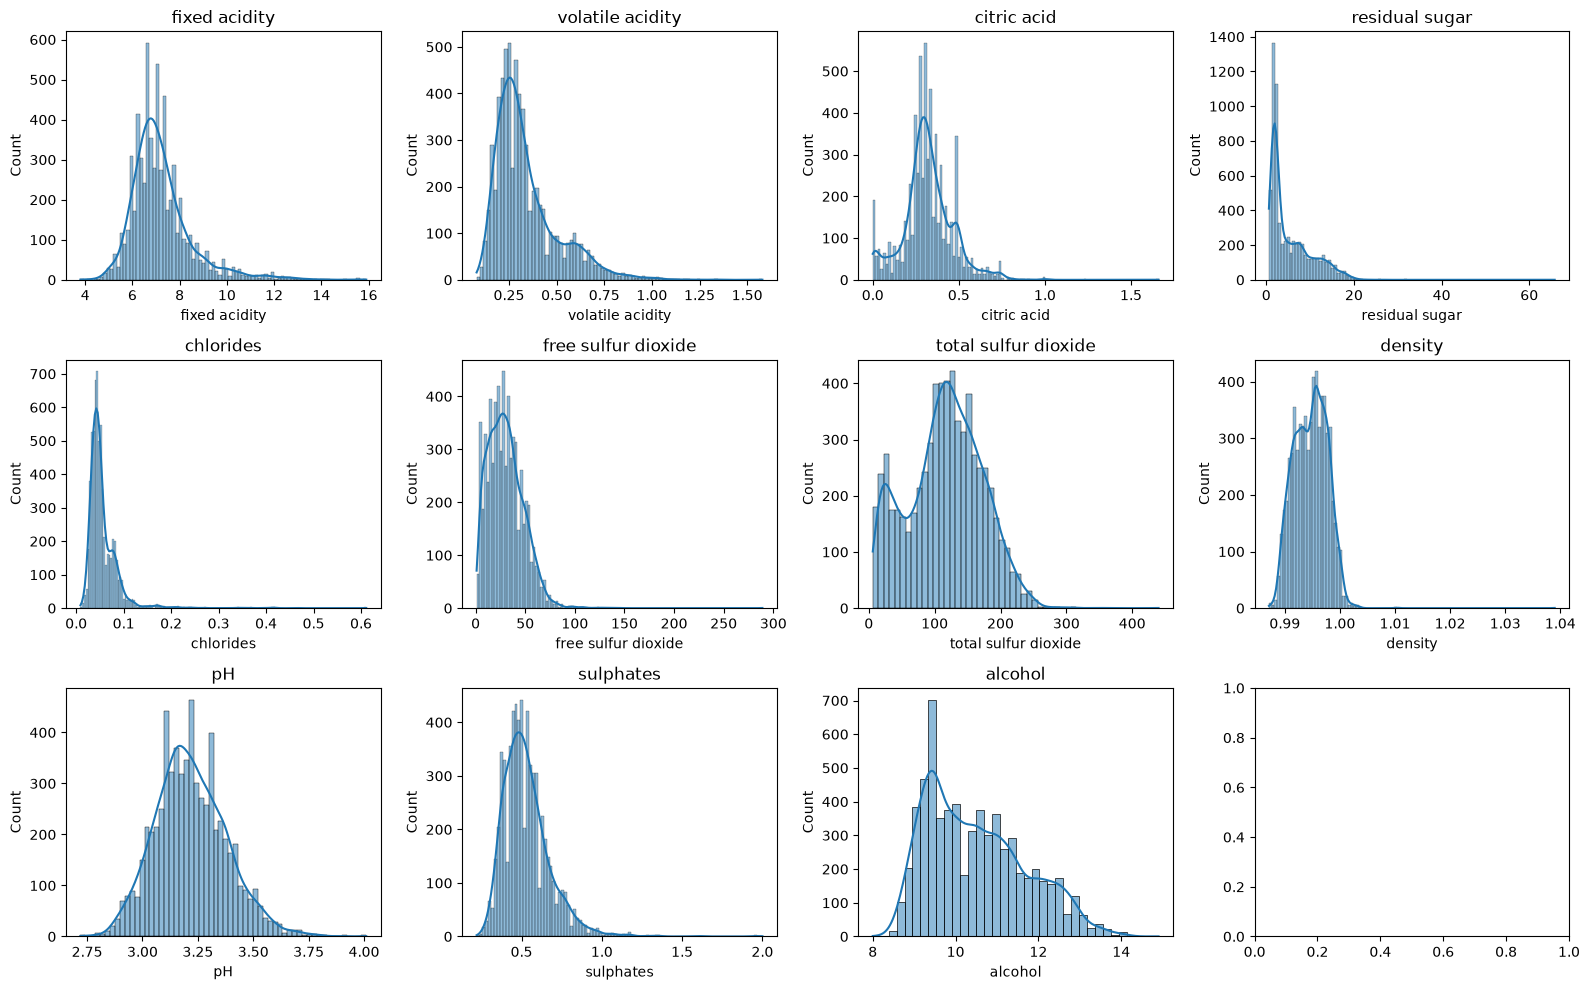

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
numeric_cols = df.select_dtypes(include="number").columns.drop("quality")
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("outputs/01_feature_distributions.png")
plt.show()

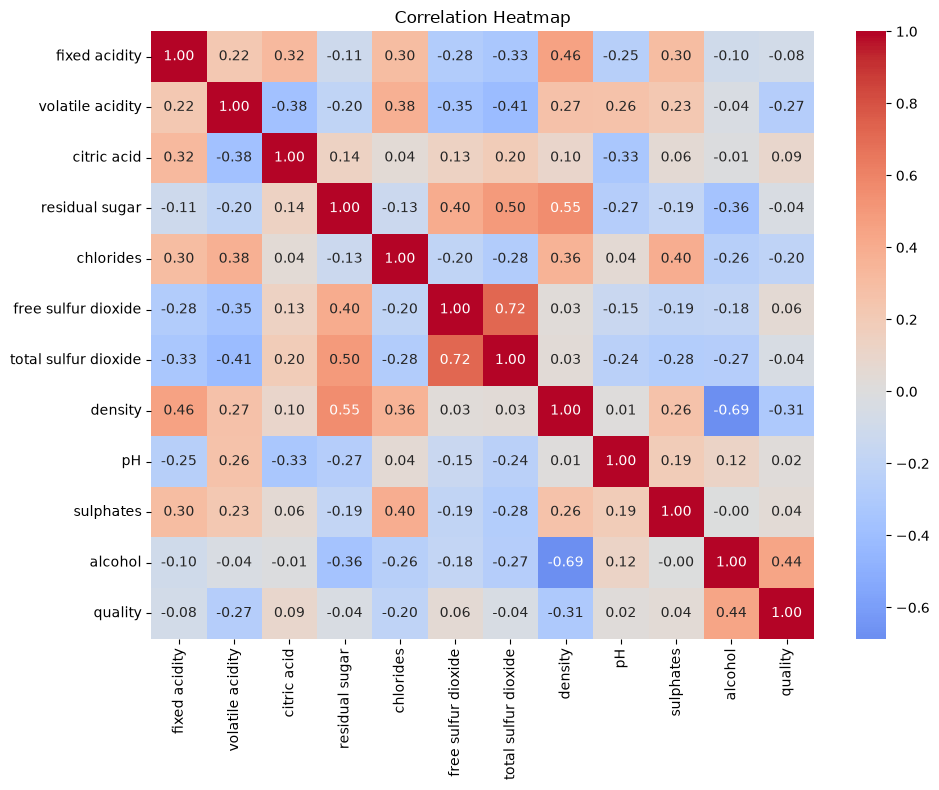

In [7]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/02_correlation_heatmap.png")
plt.show()

## 3. Class imbalance

Wine quality scores are heavily concentrated around 5-6, with very few samples at the extremes (3, 4, 8, 9).
Training a classifier directly on the raw 7-class label would struggle on the rare classes and risks the
model simply predicting the majority class. To make the problem more tractable and the classes more balanced,
we bin quality into 3 categories: **low** (3-4), **medium** (5-6), **high** (7-9).

In [8]:
def bin_quality(q):
    if q <= 4:
        return "low"
    elif q <= 6:
        return "medium"
    else:
        return "high"

df["quality_class"] = df["quality"].apply(bin_quality)
df["quality_class"].value_counts()

quality_class
medium    4974
high      1277
low        246
Name: count, dtype: int64

## 4. Train/test split (stratified) and scaling

In [9]:
feature_cols = [c for c in df.columns if c not in ["quality", "quality_class", "wine_type"]]
X = df[feature_cols]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((5197, 11), (1300, 11))

## 5. Train and evaluate 3 classifiers

A naive baseline is included for context: always predicting the majority class ("medium"). Any real
model needs to clearly beat this baseline to demonstrate it learned something useful — and, more
importantly, needs to be checked on *each* class individually, not just overall accuracy, since overall
accuracy can look good while completely failing on a minority class.

In [10]:
baseline_accuracy = (y_test.value_counts(normalize=True).max())
print(f"Baseline ('always predict majority class') accuracy: {baseline_accuracy:.3f}")

Baseline ('always predict majority class') accuracy: 0.765


In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42, max_iter=2000),
    "SVC": SVC(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro", zero_division=0)
    results[name] = {"model": model, "preds": preds, "accuracy": acc, "macro_f1": macro_f1}
    print(f"=== {name} (accuracy: {acc:.3f}, macro-F1: {macro_f1:.3f}) ===")
    print(classification_report(y_test, preds, zero_division=0))

=== Random Forest (accuracy: 0.850, macro-F1: 0.581) ===
              precision    recall  f1-score   support

        high       0.80      0.55      0.65       256
         low       1.00      0.10      0.19        49
      medium       0.86      0.96      0.91       995

    accuracy                           0.85      1300
   macro avg       0.88      0.54      0.58      1300
weighted avg       0.85      0.85      0.83      1300

=== SGD Classifier (accuracy: 0.753, macro-F1: 0.321) ===
              precision    recall  f1-score   support

        high       0.33      0.06      0.10       256
         low       0.00      0.00      0.00        49
      medium       0.77      0.97      0.86       995

    accuracy                           0.75      1300
   macro avg       0.37      0.34      0.32      1300
weighted avg       0.65      0.75      0.68      1300



=== SVC (accuracy: 0.785, macro-F1: 0.408) ===
              precision    recall  f1-score   support

        high       0.62      0.25      0.35       256
         low       0.00      0.00      0.00        49
      medium       0.80      0.96      0.87       995

    accuracy                           0.78      1300
   macro avg       0.47      0.40      0.41      1300
weighted avg       0.73      0.78      0.74      1300



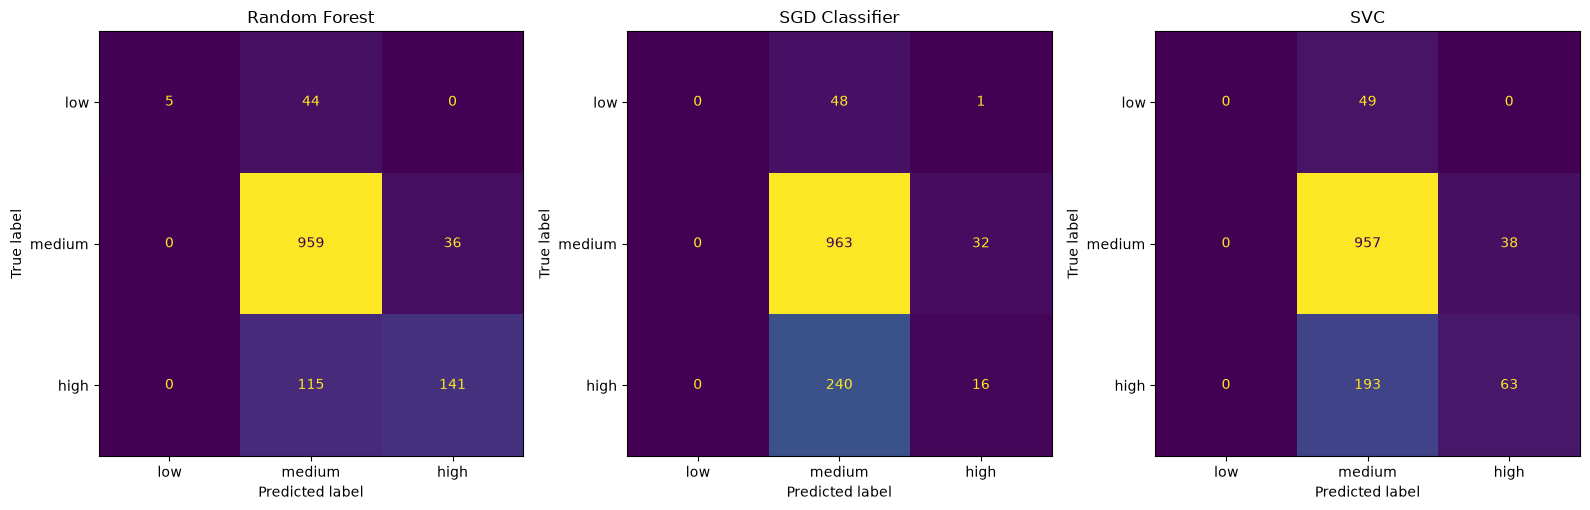

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"], labels=["low", "medium", "high"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["low", "medium", "high"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("outputs/03_confusion_matrices.png")
plt.show()

## 6. Feature importance (Random Forest)

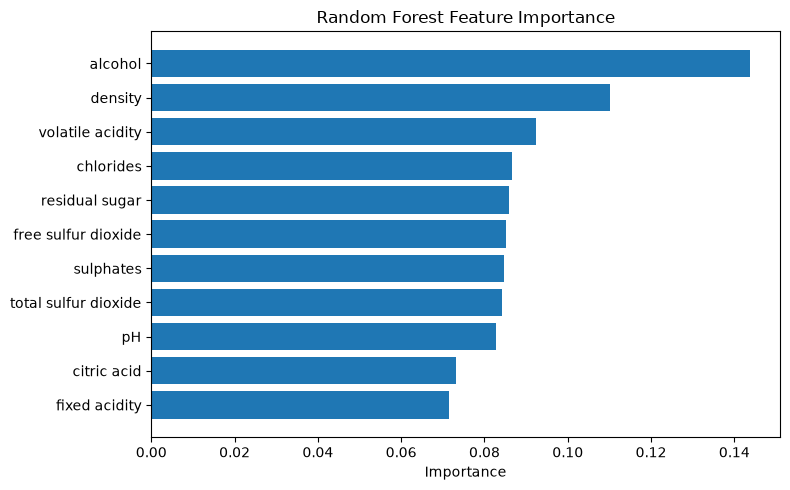

In [13]:
importances = pd.Series(results["Random Forest"]["model"].feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.barh(importances.index[::-1], importances.values[::-1])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("outputs/04_feature_importance.png")
plt.show()

## 7. Model comparison

In [14]:
comparison = pd.DataFrame({
    name: {"Accuracy": res["accuracy"], "Macro F1": res["macro_f1"]} for name, res in results.items()
}).T.sort_values("Accuracy", ascending=False)
comparison.loc["Baseline (majority class)"] = [baseline_accuracy, None]
comparison.to_csv("outputs/model_comparison.csv")
comparison

,Accuracy,Macro F1
Random Forest,0.850000,0.581390
SVC,0.784615,0.408440
SGD Classifier,0.753077,0.320814
Baseline (majority class),0.765385,NaN


## 8. Conclusion

**Accuracy alone is misleading here.** The baseline row above shows that always predicting "medium" already
scores close to Random Forest's headline accuracy, because "medium" makes up the vast majority of the test
set. Macro-F1 (which weighs all 3 classes equally, regardless of size) tells a very different story than
accuracy does, and the per-class `classification_report` output above is the most honest view: **all three
models struggle badly on the minority "low" class** — SGD and SVC never predict it at all (0% recall), and
Random Forest, while best of the three, still only recalls about 10% of actual low-quality wines.

Ranked by accuracy *and* macro-F1, Random Forest is still the strongest of the three models, and its
feature importances (alcohol, density, volatile acidity) are consistent with established wine-quality
research — so it is the right choice to build on. But **it is not yet a reliable tool for flagging
low-quality wine**, which is arguably the more business-critical use case (catching bad batches) versus
correctly labeling the abundant medium-quality middle. Before this could be deployed for that purpose,
it would need explicit class-imbalance handling — e.g. `class_weight="balanced"`, oversampling the
minority class (SMOTE), or collecting more low/high-quality samples — none of which was applied here, so
the current models should be read as a baseline, not a finished solution.